### Import all the necessary libs

In [1]:
!pip install gymnasium
!pip install matplotlib
!pip install pandas
!pip install imageio imageio[ffmpeg]

import sys
import os
import numpy as np
import matplotlib.pyplot as plt


import gymnasium as gym
current_dir = os.getcwd()
gym_multigrid_path = os.path.join(current_dir, 'gym-multigrid')
if gym_multigrid_path not in sys.path:
    sys.path.append(gym_multigrid_path)



try:
    from gym_multigrid.envs import MARL_env
    print("Importation de MARL_env réussie !")
except ModuleNotFoundError:
    print(f"Warning: Could not import 'gym_multigrid.envs'. Check that the path '{gym_multigrid_path}' contains this module.")

from matplotlib.colors import ListedColormap
from collections import deque
import random
import copy
from collections import OrderedDict
import pandas as pd
import time

seed = 42
np.random.seed(seed)
random.seed(seed)

Importation de MARL_env réussie !


# Introduction to the Practical Session: Offline and Online Planning in Reinforcement Learning

Today, we will explore and implement two fundamental strategies that allow an autonomous agent to navigate and make decisions in a  environment.

The objective of this session is to implement, analyze, and compare two distinct approaches:

### 1. Offline Planning (Basic Q-Learning)
First, you will use the standard Q-Learning algorithm. This is a **model-free** approach where the learning process occurs entirely **before** the final execution. The agent will explore an obstacle-free environment through trial and error to build its Q-Table. Once this training phase is complete, the agent possesses an optimal global policy that it simply executes to reach its goal.

### 2. Online Planning (Model-Based Finite Horizon Q-Learning)
Next, we will challenge our pre-trained agent by modifying its environment. We will introduce new, static obstacles (walls) into the grid and observe how the initial policy fails. 

To solve this, you will implement a **model-based** approach where learning happens **on-the-fly**. Using a predictive safety mechanism (a shield), the agent will look ahead to anticipate collisions. If it detects that its current policy leads to a crash, it will use its internal model of the environment to mentally simulate the consequences of its actions over a limited horizon ($k$ steps). It will then locally update its policy to safely bypass the new obstacle and continue its progression toward the goal.



### Creating the MARL Environment Functions

We structure this environment into two main components:

1. **Training Environment:** Used for the initial pre-training of the agent.
2. **Testing Environment:** Used to evaluate and test our finite horizon Q-learning approach.

In [2]:
class MultiAgentEnvWrapper:
    """
    Wrapper class for CustomMultiAgentEnv that distinguishes between training and testing phases
    """
    
    def __init__(self, is_testing=False, width=10, height=10, max_steps=100, seed=None,
                 agent_positions=None, goal_positions=None, walls=None):
        self.is_testing = is_testing
        self.width = width
        self.height = height
        self.max_steps = max_steps
        self.seed = seed
        self.envs = []  # stores all environments created
        self.initial_states = []
        
        if agent_positions is None or goal_positions is None:
            raise ValueError("agent_positions and goal_positions must be provided")
        
        # Training mode: one env per agent/goal pair
        if not is_testing:
            for agent_pos, goal_pos in zip(agent_positions, goal_positions):
                agents = [{"start": agent_pos, "goal": goal_pos}]
                env = MARL_env.CustomMultiAgentEnv(
                    width=width,
                    height=height,
                    max_steps=max_steps,
                    seed=seed,
                    agents=agents
                )
                
                # Add walls if specified
                if walls:
                    for wall_x, wall_y in walls:
                        env.add_wall(wall_x, wall_y)
                
                self.envs.append(env)
                self.initial_states.append(env.reset()[0])  # Get first agent's observation
        
        # Test mode: one env with all agents and goals
        else:
            agents = [{"start": start, "goal": goal} for start, goal in zip(agent_positions, goal_positions)]
            env = MARL_env.CustomMultiAgentEnv(
                width=width,
                height=height,
                max_steps=max_steps,
                seed=seed,
                agents=agents
            )
            
            # Add walls if specified
            if walls:
                for wall_x, wall_y in walls:
                    env.add_wall(wall_x, wall_y)
            
            self.envs.append(env)
            self.initial_states.append(env.reset())
    
    def reset(self, idx=0):
        return self.envs[idx].reset(), self.get_agent_position(idx=idx)
    def step(self, actions, idx=0):
        """
        Execute a step in the environment with the given actions for each agent.
        
        Args:
            actions: List of actions, one per agent or single action
            idx: Index of the environment to use
            
        Returns:
            observations: List of observations for each agent
            rewards: List of rewards for each agent
            terminated: If the episode is terminated by reaching goals
            truncated: If the episode is truncated by exceeding max steps
            info: Additional information
        """
        # Make sure we're using the right environment
        env = self.envs[idx]
        
        # Different handling for training vs testing
        if not self.is_testing:
            # Training mode - one action for one agent
            if not isinstance(actions, list):
                obs, rewards, terminated, truncated, info = env.step([actions])
                return obs[0], rewards[0], terminated, truncated, info  # Return just the first agent's results
            else:
                obs, rewards, terminated, truncated, info = env.step(actions)
                return obs[0], rewards[0], terminated, truncated, info  # Return just the first agent's results
        else:
            # Testing mode - list of actions for multiple agents
            if not isinstance(actions, list):
                # Convert single action to list if needed
                actions = [actions]
            
            # Make sure we have enough actions for all agents
            if len(actions) < len(env.agents):
                actions = actions + [0] * (len(env.agents) - len(actions))
            obs, rewards, terminated, truncated, info = env.step(actions)
            # Call the environment's step method
            return obs, rewards, terminated, truncated, info

    def visualize(self, idx=0, highlight_masks=None, show=True):
        """
        Visualize the environment at the specified index
        
        Args:
            idx: Index of the environment to visualize
            highlight_masks: Optional mask to highlight specific cells
            show: Whether to display the image (True) or just return it (False)
        
        Returns:
            numpy.ndarray: The rendered grid image
        """
        grid_image = self.envs[idx].visualize(highlight_masks=highlight_masks, show=show)
        return grid_image
    
    def get_action_space(self):
        # 1: left, 2: right, 3: up, 4: down, 0: stay
        return list(range(5))
    
    def all_agents_at_goals(self, idx=0):
        return self.envs[idx].all_agents_at_goals()
    
    def run_random_agents(self, max_steps=100, idx=0):
        self.envs[idx].run_random_agents(max_steps)
    
    def get_agent_position(self, idx=0):
        """Get the current position of the agent."""
        if self.is_testing:
            return tuple(self.envs[0].agents[idx].pos)
        else:
            return tuple(self.envs[idx].agents[0].pos)
    def collision():
        return MARL_env.CustomMultiAgentEnv.are_agents_colliding()
    def get_agent_goal(self, idx=0):
        """
        Get the goal position of the agent.
        
        Args:
            idx: Index of the agent whose goal position to retrieve
            
        Returns:
            tuple: (x, y) coordinates of the agent's goal position
        """
        if self.is_testing:
            # In testing mode, get the goal for the specified agent
            env = self.envs[0]
            return tuple(env.agent_goals[idx])
        else:
            # In training mode, get the goal for the single agent in the environment
            env = self.envs[idx]
            return tuple(env.agent_goals[0])
    def get_lava_pos(self):
        """
        Get the positions of lava cells in the environment.
        
        Returns:
            list: List of (x, y) coordinates of lava positions
        """
        return self.envs[0].lava_positions
    def render(self, idx=0):
        """
        Alias for visualize to maintain compatibility with standard RL rendering loops.
        We set show=False because the video recorder only needs the pixel array, 
        not to pop up a display window.
        """
        return self.visualize(idx=idx, show=False)

### Q-Learning

In the context of a finite Markov Decision Process (MDP), the **Q-Table** is the matrix representation of the empirical action-value function $Q: \mathcal{S} \times \mathcal{A} \rightarrow \mathbb{R}$. Each entry $Q(s, a)$ estimates the expected future discounted rewards obtained by taking action $a$ from state $s$, and subsequently following the optimal policy.

The optimization of these values is performed iteratively off-policy via the **update rule**. The agent corrects its estimation by minimizing the Temporal Difference (TD) error derived from the Bellman optimality equation:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Where:
*   $\alpha \in ]0, 1]$: **Learning rate** (step size of the stochastic optimization).
*   $r$: Immediate **reward signal** evaluated upon transitioning to the new state $s'$.
*   $\gamma \in [0, 1]$: **Discount factor** (exponential decay weighting future rewards).
*   $\left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$: The **TD error**, where the term $r + \gamma \max_{a'} Q(s', a')$ acts as the learning target.

After the convergence of the algorithm, the agent's optimal policy $\pi^*(s)$ is defined for each state as the action that maximizes the Q-value in the Q-table for that specific state: 

$$\pi^*(s) = \arg\max_a Q(s, a)$$



### TO DO: Agent Implementation

**1) Reward Design**
Navigate to the external environment file: `gym-multigrid/gym_multigrid/envs/MARL_env.py`. Modify the `step` function to implement a reward logic that effectively guides the agent toward its goal.

**2) Optimal Policy Implementation**
Complete the `best_action(self, array)` method. Implement the selection logic based on the mathematical definition of the optimal policy $\pi^*(s)$ to identify the best action from a given set of Q-values.

**3) Action Selection Logic**
Complete the `select_action(self, state, eval=False)` method. Ensure the agent selects the best possible action from the Q-table when it is not exploring.

**4) Q-Learning Update Rule**
Complete the `q_learning(self, state, action, reward, next_state, done)` method. Implement the temporal difference update formula to adjust the Q-values based on the agent's experience.

In [3]:
import numpy as np
import pandas as pd
from collections import OrderedDict
import random

class QLearningAgent:

    def __init__(self, 
                 state_dim, 
                 action_dim, 
                 lr=0.1, 
                 gamma=0.99, 
                 epsilon=0.4):
        
        # environment
        self.state_dim = state_dim
        self.action_dim = action_dim

        # hyperparameters
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon

        # q-table
        self.q_table = dict()

    def action_space(self):
        return [0, 1, 2, 3, 4]  # UP, DOWN, LEFT, RIGHT, STOP

    def best_action(self, array):
        return np.argmax(array)
    
    def select_action(self, state, eval=False):
        state_index = self.state_to_position(state)

        if state_index not in self.q_table:
            self.q_table[state_index] = np.zeros(self.action_dim)
        
        if not eval and np.random.rand() < self.epsilon:
            return np.random.choice(self.action_dim)
        action = self.best_action(self.q_table[state_index])
        return action
    
    def q_learning(self, state, action, reward, next_state, done): 
        self.q_table[state][action] += self.lr * (reward + self.gamma * np.max(self.q_table[next_state]) - self.q_table[state][action])

    def update(self, state, action, reward, next_state, done):
        state_index = (self.state_to_position(state))
        next_state_index = (self.state_to_position(next_state))
        
        if state_index not in self.q_table:
            self.q_table[state_index] = np.zeros(self.action_dim)

        if next_state_index not in self.q_table:
            self.q_table[next_state_index] = np.zeros(self.action_dim)

        # Mise à jour classique Q-learning (sans sauvegarde dans un modèle ni planification)
        self.q_learning(state_index, action, reward, next_state_index, done)
        
    def state_to_position(self, state):
        """
        Convert state to a hashable position representation.
        """
        if isinstance(state, tuple):
            if len(state) == 2 and isinstance(state[1], tuple):
                return state[1]
            return state
        elif isinstance(state, list):
            return tuple(state)
        elif isinstance(state, np.ndarray):
            if hasattr(self, 'env_wrapper') and hasattr(self, 'agent_idx'):
                return self.env_wrapper.get_agent_position(self.agent_idx)
            else:
                print("Cannot extract position from numpy array without env_wrapper reference")
                return (0, 0)
        else:
            print(f"Error: Unexpected state type: {type(state)}")
            return (0, 0)

    def print_tables(self, name='qtable'):
        if name == 'qtable':
            table = self.q_table
            # Assurez-vous que SHAPE est défini globalement ou passez-le en paramètre
            print(f"{len(table)} states have been reached.")
            col_names=['UP', 'DOWN', 'LEFT', 'RIGHT', 'STOP']
        else:
            print("Invalid table name.")
            return

        ordered_coords_dict = OrderedDict(sorted(table.items())).copy()
        df = pd.DataFrame.from_dict(ordered_coords_dict, orient='index', columns=col_names)
        df = df.round(2)
        print(df)

        return len(table)
    
    def tables_2(self):
        return [len(self.q_table)]

### Functions for Pretraining all the agents
Just run the cell 

In [4]:
def train_agent(env_wrapper, agent, num_episodes=1000, max_steps=1000, print_process=False, agent_idx=0, walls=None):
    """
    Trains an agent in a given environment over multiple episodes.
    Re-adds walls after every environment reset.
    """
    if walls is None:
        walls = []
        
    all_rewards = []

    for episode in range(num_episodes):
        
        state = env_wrapper.reset(agent_idx) 
        
        for x, y in walls:
            env_wrapper.envs[agent_idx].add_wall(x, y)
            
        total_reward = 0
        
        if print_process and episode % 10 == 0:
            print(f"Episode {episode}, Agent {agent_idx+1}")
        
        for i in range(max_steps):
            action = agent.select_action(state, eval=False)
            next_state, reward, terminated, truncated, info = env_wrapper.step(action, agent_idx)
            done = terminated or truncated
            
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            
            if done:
                break

        all_rewards.append(total_reward)

        if print_process and episode % 10 == 0:
            print(f"Episode {episode}, Total Reward for Agent {agent_idx+1}: {total_reward}")
    
    return all_rewards
def smooth(data, weight=0.9):  
    """
    Lisse les données en utilisant un facteur de pondération (smooth).
    :param data: La liste des données à lisser.
    :param weight: Le facteur de pondération utilisé pour le lissage.
    :return: La liste des données lissées.
    """
    last = data[0]
    smoothed = list()
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)                    
        last = smoothed_val                                
    return smoothed

def plot_rewards_for_all_agents(all_rewards, filename='rewards.png'):
    """
    Trace les récompenses pour tous les agents après l'entraînement.
    
    :param all_rewards: Une liste des récompenses pour chaque agent.
    :param filename: Le nom du fichier pour enregistrer le graphique.
    """
    plt.figure(figsize=(10, 6))

    for idx, rewards in enumerate(all_rewards):
        smoothed_rewards = smooth(rewards)  # Lissage des récompenses
        plt.plot(smoothed_rewards, label=f"Agent {idx+1}")  # Tracer les récompenses lissées
    
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Q-learning for Multiple Agents')
    plt.legend()
    plt.show()

    print(f"Plot saved as {filename}")

def train_all_agents(env_wrapper, agents, num_episodes=1000, max_steps=1000, walls=None):
    """
    Trains multiple agents independently in a multi-agent environment.
    Passes the walls parameter to the individual training function.
    """
    all_agents_rewards = []
    
    for idx, agent in enumerate(agents):
        print(f"\nTraining Agent {idx+1}...")
        seed = 42
        np.random.seed(seed)
        random.seed(seed)
        
        # Pass the walls parameter here
        agent_rewards = train_agent(
            env_wrapper, 
            agent, 
            num_episodes, 
            max_steps, 
            agent_idx=idx, 
            walls=walls
        )
        all_agents_rewards.append(agent_rewards)
    
    return all_agents_rewards


def print_qtables(agents):
    for idx, agent in enumerate(agents):
        print(f"\nQ-table for Agent {idx+1}:")
        agent.print_tables('qtable')  





### Part 1: Offline Planning Execution

from sympy import python


In this final section, you will instantiate the environment, pre-train your agent using standard Q-Learning, and visualize its learned policy.

**TODO 1: Initialize and Train the Agent**
Use the `create_and_pretrain_agents` function to create and train your agent. 
Make sure to pass the correct arguments:
*   Use the predefined `width`, `height`, `agent_positions`, and `goal_positions`.
*   Set `num_agents` to `1`.
*   Set `training_episodes` to `2000` and `max_training_steps` to `200`.
*   Keep the environment free of obstacles by leaving `walls=[]`.
*   Set `visualize=True` to plot the training rewards.
*   *Hint: Remember to unpack the four variables returned by this function (`agents`, `train_env`, `test_env`, and `Qstar`).*

**TODO 2: Record and Display the Policy**
Once the training is complete, use the `record_policy_video` function to see your agent in action!
*   Pass the `test_env` and `agents` you just created.
*   Choose a `filename` (e.g., `"agent_policy.mp4"`).
*   Set `max_steps` to `50` and `fps` to `5`.




===== Initializing environment with 1 agents =====

===== Creating and training Agent 1 =====


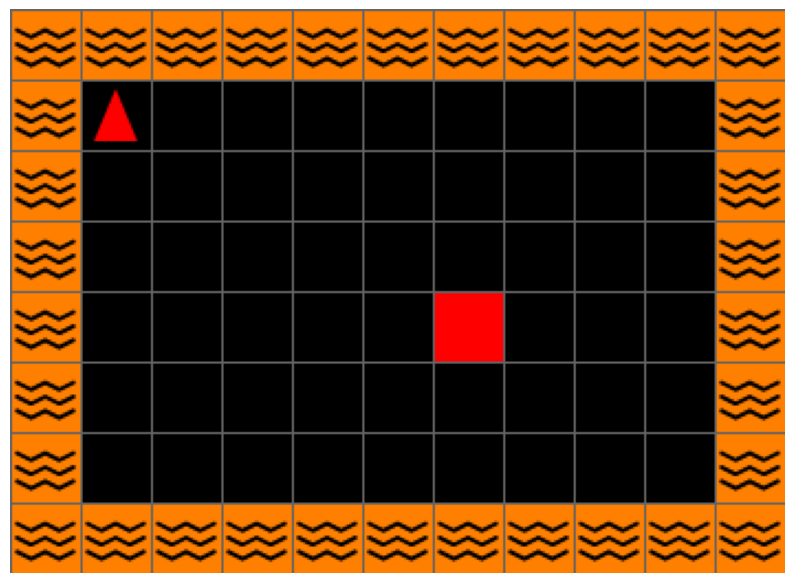


Training Agent 1...


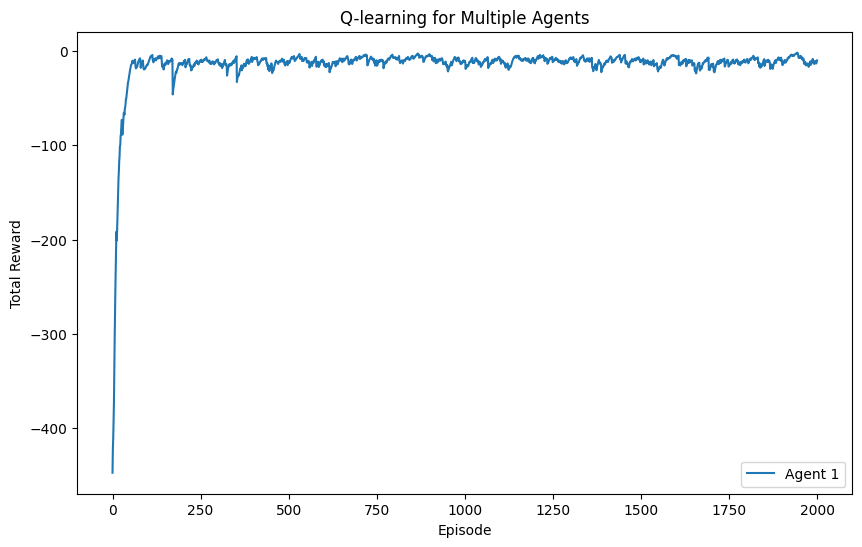

Plot saved as rewards.png

===== Recording video: agent_policy.mp4 =====
Episode finished at step 8.
Success! Video saved locally as: agent_policy.mp4


In [5]:
import random
import imageio
import base64
from IPython.display import HTML, display

def reset_with_walls(env_wrapper, walls, if_reset=True):
    """
    Resets the environment and adds the specified walls.
    """
    # Reset the environment
    if if_reset:
        result = env_wrapper.reset()
    else:
        result = env_wrapper
    
    # Add the defined walls
    for x, y in walls:
        for env in env_wrapper.envs:
            env.add_wall(x, y)
    
    # Return tuple of (env, first agent position) if reset, otherwise just env
    if if_reset:
        return result


def generate_random_positions(num_agents, width=20, height=20, min_distance=4):
    """
    Generates random starting and goal positions.
    Args:
        num_agents: Number of agents
        width: Width of the grid
        height: Height of the grid
        min_distance: Minimum distance between any two agents/goals
        
    Returns:
        tuple: (agent_positions, goal_positions)
    """
    agent_positions = []
    goal_positions = []
    all_positions = []  
    
    def is_valid_position(pos, existing_positions):
        x, y = pos
        
        # Check if within bounds (with margin to avoid edge positions)
        if x < 1 or x >= width-1 or y < 1 or y >= height-1:
            return False
        
        for ex_pos in existing_positions:
            dist = abs(ex_pos[0] - x) + abs(ex_pos[1] - y)  # Manhattan distance
            if dist < min_distance:
                return False
                
        return True
    
    # Generate agent positions
    for _ in range(num_agents):
        while True:
            # Random position within grid bounds
            pos = (random.randint(1, width-2), random.randint(1, height-2))
            
            if is_valid_position(pos, all_positions):
                agent_positions.append(pos)
                all_positions.append(pos)
                break
    
    # Generate goal positions
    for _ in range(num_agents):
        while True:
            # Random position within grid bounds
            pos = (random.randint(1, width-2), random.randint(1, height-2))
            
            if is_valid_position(pos, all_positions):
                goal_positions.append(pos)
                all_positions.append(pos)
                break
    
    return agent_positions, goal_positions


def create_and_pretrain_agents(
    num_agents=4, 
    width=1, 
    height=1, 
    training_episodes=2000, 
    max_training_steps=200,
    use_random_positions=False,
    random_min_distance=4,
    agent_positions=None,
    goal_positions=None,
    walls=[],
    visualize=False,
):
    """
    Creates and trains agents with specified or randomly generated positions,
    then sets up a shared test environment.
    
    Args:
        num_agents: Number of agents to create
        width: Width of the grid environment
        height: Height of the grid environment
        training_episodes: Number of episodes for training each agent
        max_training_steps: Maximum number of steps per training episode
        use_random_positions: Whether to generate random positions
        random_min_distance: Minimum distance between random positions
        agent_positions: List of tuples with agent positions (ignored if use_random_positions=True)
        goal_positions: List of tuples with goal positions (ignored if use_random_positions=True)
        walls: List of tuples with wall positions
        
    Returns:
        tuple: (agents, train_env, test_env, Qstar)
    """
    print(f"\n===== Initializing environment with {num_agents} agents =====")
    
    if use_random_positions:
        print(f"Generating random positions with minimum distance {random_min_distance}...")
        agent_positions, goal_positions = generate_random_positions(
            num_agents=num_agents, 
            width=width, 
            height=height, 
            min_distance=random_min_distance
        )
    else:
        if agent_positions is None or goal_positions is None:
            print("Using default positions...")
            agent_positions = [(3,2),(2,3)] 
            goal_positions = [(3,4),(4,3)] 
            
            # Truncate if too many for num_agents
            agent_positions = agent_positions[:num_agents]
            goal_positions = goal_positions[:num_agents]
            
            # Or extend with duplicates if not enough
            while len(agent_positions) < num_agents:
                agent_positions.append((1, 1))
            while len(goal_positions) < num_agents:
                goal_positions.append((width-2, height-2))
    
    train_env = MultiAgentEnvWrapper(
        is_testing=False,
        width=width,
        height=height,
        agent_positions=agent_positions,
        goal_positions=goal_positions,
        walls=walls
    )
    
    # Create and train agents
    agents = []
    for i in range(len(agent_positions)):
        if visualize:
            print(f"\n===== Creating and training Agent {i+1} =====")
            train_env.visualize(i)
        reset_with_walls(train_env, walls, if_reset=False)
        agent = QLearningAgent(state_dim=width*height, action_dim=5)
        agent.env_wrapper = train_env
        agent.agent_idx = i
        agents.append(agent)
    

    all_rewards = train_all_agents(
        train_env, 
        agents, 
        num_episodes=training_episodes, 
        max_steps=max_training_steps, 
        walls=walls
    )
    # Copy Q-tables from all agents to a shared Q-table dictionary
    Qstar = {}
    for i, agent in enumerate(agents):
        Qstar[i] = agent.q_table.copy()
    
    # Create test environment (shared environment with all agents)
    test_env = MultiAgentEnvWrapper(
        is_testing=True,
        width=width,
        height=height,
        agent_positions=agent_positions,
        goal_positions=goal_positions,
        walls=walls
    )
    
    # Display the test environment
    if visualize:
        plot_rewards_for_all_agents(all_rewards)
    
    # Update agents to use the test environment
    for i, agent in enumerate(agents):
        agent.env_wrapper = test_env
    
    # Reset the environment
    reset_with_walls(test_env, walls, if_reset=True)
    
    return agents, train_env, test_env, Qstar


def record_policy_video(test_env, agents, filename="agent_policy.mp4", max_steps=100, fps=5):
    """
    Plays an episode using the learned policy and saves/displays it as a video
    directly in the Jupyter Notebook using HTML/Base64.
    """
    print(f"\n===== Recording video: {filename} =====")
    frames = []
    
    try:
        frame = test_env.render()
        if frame is not None:
            frames.append(frame)
    except Exception as e:
        print(f"Error capturing initial frame: {e}")
        return

    for step in range(max_steps):
        actions = []
        
        for i, agent in enumerate(agents):
            agent_pos = test_env.get_agent_position(i)
            action = agent.select_action(agent_pos, eval=True)
            actions.append(action) 
            
        res = test_env.step(actions)
        
        dones = res[2]
        
        frame = test_env.render()
        if frame is not None:
            frames.append(frame)
            
        is_done = all(dones) if isinstance(dones, (list, tuple)) else dones
        if is_done:
            print(f"Episode finished at step {step+1}.")
            break

    if frames:
        try:
            imageio.mimsave(filename, frames, fps=fps, macro_block_size=1)
            print(f"Success! Video saved locally as: {filename}")
            
            # Embed video in Notebook via HTML
            video_file = open(filename, "rb").read()
            video_b64 = base64.b64encode(video_file).decode()
            
            html_code = f'''
            <video width="640" height="480" controls autoplay loop>
              <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
              Your browser does not support the HTML video tag.
            </video>
            '''
            display(HTML(html_code))
            
        except Exception as e:
            print(f"Error saving or displaying video: {e}")
    else:
        print("Failed: No frames could be captured. Ensure env.render() returns an rgb array.")

# ==========================================
# EXECUTION BLOCK
# ==========================================

height = 8
width = 11
agent_positions = [(1,1)]  
goal_positions  = [(6,4)]
# TODO 1: Use the create_and_pretrain_agents function
agents, train_env, test_env, Qstar = create_and_pretrain_agents(
    num_agents=1,
    width=width,
    height=height,
    training_episodes=2000,
    max_training_steps=200,
    agent_positions=agent_positions,
    goal_positions=goal_positions,
    walls=[],
    visualize=True
)

# TODO 2: Use the record_policy_video function
record_policy_video(test_env, agents, filename="agent_policy.mp4", max_steps=50, fps=5)

### What happens if we add a wall in the testing environnement after the training ? 


In [6]:
walls = [(3, 2), (3, 3), (3, 4)]  # Vertical wall at x=3 from y=2 to y=4

reset_with_walls(test_env, walls, if_reset=True)

record_policy_video(test_env, agents, filename="policy_with_walls.mp4", max_steps=50, fps=5)


===== Recording video: policy_with_walls.mp4 =====
Episode finished at step 8.
Success! Video saved locally as: policy_with_walls.mp4



## Part 2
### Model-Based Finite Horizon Q-Learning with Predictive Safety

To solve this problem, we will use a technique called **Model-Based Finite Horizon Q-Learning**. 

The core idea is to take an agent previously trained in an obstacle-free environment, introduce new obstacles, and adapt its behavior "on the fly" to avoid them. To do this efficiently, the agent will only plan ahead for a limited number of steps, which we define as our planning horizon, **$k$**.

We will break this process down into five main steps:

1. **Define the Environment Models**
   We first need to create an internal representation of the environment. This includes defining a transition model (the dynamics of how the agent moves) and a reward model to simulate the outcomes of its actions.

2. **Compute the $k$-Step Reachable Set**
   Based on the agent's current position, we calculate the *$k$-step reachable set*. This is the localized subset of all possible states the agent could potentially reach within the next $k$ steps.

3. **Implement a Safety Shield**
   We define a "shield"—a supervisory controller that intercepts the agent's actions before they are executed. The shield checks if an immediate action leads to an unsafe state (like lava). If danger is detected, it blocks the original action and replaces it with a safe fallback, such as the "stay" action (action `0`).

4. **Predictive Safety Check (The Trigger)**
   Before applying any new learning, we simulate the agent's *current* policy $k$ steps into the future to see where its current knowledge leads. 
   * **If the path is safe:** The agent continues executing its original policy without any interference.
   * **If the policy leads to lava:** This triggers our localized retraining algorithm to find a detour.

5. **Execute Finite Horizon Q-Learning**
   If the safety check detects upcoming danger, we run the Q-Learning algorithm. However, instead of taking physical steps in the actual environment, the agent simulates future states and rewards using the models defined in Step 1. It then performs its Q-table updates exclusively within the confines of the safe $k$-step reachable set to learn a new, safe path.

### Movement Model

In [7]:
def model_state(state,action):

    pos= state
    next_pos_array = np.array(pos)
    
    if action == 0:
        next_pos = pos  
    elif action == 1:  
        next_pos_array[0] -= 1
        next_pos = tuple(next_pos_array)
    elif action == 2: 
        next_pos_array[0] += 1
        next_pos = tuple(next_pos_array)
    elif action == 3:  
        next_pos_array[1] -= 1
        next_pos = tuple(next_pos_array)
    elif action == 4:  
        next_pos_array[1] += 1
        next_pos = tuple(next_pos_array)
    return next_pos

### SETS

* Computing the reachable set in `n_steps`
* Computing the `n_steps` unsafe set for an agent as the intersection between its reachable set and static obstacles


### Question 
* What could look like the unsafe set if we add another agent without any communication and not knowing what it will do ?


In [8]:
from collections import deque

def is_static_obstacle(pos, env, agent_idx=0):
    if env.is_testing:
        grid = env.envs[0].grid
    else:
        grid = env.envs[agent_idx].grid if agent_idx < len(env.envs) else None
    
    if grid is None:
        return False
    
    x, y = pos
    cell = grid.get(x, y)
    if hasattr(cell, "__class__"):
        cell_type = cell.__class__.__name__
        return cell_type in ["EnterableLava"]
    return False

def has_line_of_sight(start_pos, target_pos, env, agent_idx=0, max_vision_range=None):
    if max_vision_range is not None:
        distance = abs(target_pos[0] - start_pos[0]) + abs(target_pos[1] - start_pos[1])
        if distance > max_vision_range:
            return False
    
    x0, y0 = start_pos
    x1, y1 = target_pos
    
    if env.is_testing:
        grid = env.envs[0].grid
    else:
        grid = env.envs[agent_idx].grid if agent_idx < len(env.envs) else None
    
    if grid is None:
        return True
    
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    
    x, y = x0, y0
    
    while True:
        if x == x1 and y == y1:
            return True
            
        if (x, y) != start_pos and (x, y) != target_pos:
            cell = grid.get(x, y)
            if hasattr(cell, "__class__"):
                cell_type = cell.__class__.__name__
                if cell_type in ["EnterableLava"]:
                    return False
        
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x += sx
        if e2 < dx:
            err += dx
            y += sy
    
    return True

def compute_visible_positions(env, agent_idx=0, start_pos=None, max_vision_range=None, n_steps=5):
    if start_pos is None:
        start_pos = env.get_agent_position(agent_idx)
    
    if max_vision_range is None:
        max_vision_range = n_steps
        max_vision_range = max(max_vision_range, 2)
    
    visible_positions = set()
    x0, y0 = start_pos
    
    for x in range(max(0, x0 - max_vision_range), min(env.width, x0 + max_vision_range + 1)):
        for y in range(max(0, y0 - max_vision_range), min(env.height, y0 + max_vision_range + 1)):
            target_pos = (x, y)
            distance = abs(x - x0) + abs(y - y0)
            
            if distance > max_vision_range:
                continue
            
            if is_static_obstacle(target_pos, env, agent_idx):
                visible_positions.add(target_pos)
            elif has_line_of_sight(start_pos, target_pos, env, agent_idx):
                visible_positions.add(target_pos)
    
    return visible_positions

def compute_reachable_states(env, agent_idx=0, start_pos=None, n_steps=5, limited_vision=True, max_vision_range=None):
    start_pos = start_pos or env.get_agent_position(agent_idx)
    
    visible_positions = None
    if limited_vision:
        vision_range = max_vision_range if max_vision_range is not None else n_steps
        vision_range = max(vision_range, 2)
        visible_positions = compute_visible_positions(env, agent_idx, start_pos, max_vision_range=vision_range, n_steps=n_steps)
    
    queue = deque([(start_pos, 0)])  
    visited = {start_pos} 
    reachable = {0: {start_pos}}  

    actions = [0, 1, 2, 3, 4]  

    while queue:
        pos, steps = queue.popleft()
        
        if steps >= n_steps:
            continue
            
        for action in actions:
            next_pos = model_state(pos, action)
            next_pos = (int(next_pos[0]), int(next_pos[1]))

            if action == 0:
                if next_pos not in visited:
                    visited.add(next_pos)
                    queue.append((next_pos, steps + 1))
                    if steps + 1 not in reachable:
                        reachable[steps + 1] = set()
                    reachable[steps + 1].add(next_pos)
                continue
            
            if (0 <= next_pos[0] < env.width and 0 <= next_pos[1] < env.height):
                if visible_positions is not None and next_pos not in visible_positions:
                    continue
                
                if env.is_testing:
                    grid = env.envs[0].grid
                else:
                    if agent_idx < len(env.envs):
                        grid = env.envs[agent_idx].grid
                    else:
                        continue

                cell = grid.get(*next_pos) if grid is not None else None
                if hasattr(cell, "__class__") and cell.__class__.__name__ == "EnterableLava":
                    if next_pos not in visited:
                        visited.add(next_pos)
                        if steps + 1 not in reachable:
                            reachable[steps + 1] = set()
                        reachable[steps + 1].add(next_pos)
                    continue

                if next_pos not in visited:
                    visited.add(next_pos)
                    queue.append((next_pos, steps + 1))
                    if steps + 1 not in reachable:
                        reachable[steps + 1] = set()
                    reachable[steps + 1].add(next_pos)
                    
    all_reachable = set()
    for step in reachable:
        all_reachable.update(reachable[step])
    
    return reachable, all_reachable

def compute_static_unsafe_set(env, agent_idx=0, n_steps=5, limited_vision=True, max_vision_range=None):
    _, all_reachable_agent = compute_reachable_states(
        env, agent_idx=agent_idx, n_steps=n_steps, limited_vision=limited_vision, max_vision_range=max_vision_range
    )
    
    visible_positions = None
    if limited_vision:
        agent_pos = env.get_agent_position(agent_idx)
        vision_range = max_vision_range if max_vision_range is not None else n_steps
        vision_range = max(vision_range, 2)
        visible_positions = compute_visible_positions(env, agent_idx, agent_pos, max_vision_range=vision_range, n_steps=n_steps)
    
    obstacle_positions = set()
    
    for x in range(env.width):
        for y in range(env.height):
            pos = (x, y)
            if limited_vision and visible_positions is not None:
                if pos not in visible_positions:
                    continue
            
            if is_static_obstacle(pos, env, agent_idx):
                obstacle_positions.add(pos)
    
    intersections = all_reachable_agent.intersection(obstacle_positions)
    unsafe_set = {}
    if intersections:
        unsafe_set[0] = {pos: 1 for pos in intersections}
    
    return unsafe_set

def filter_reachable_by_unsafe(reachable_dict, unsafe_positions, k=1):
    positions_to_exclude = set()
    
    if isinstance(unsafe_positions, dict):
        for step_data in unsafe_positions.values():
            if isinstance(step_data, dict):
                positions_to_exclude.update(step_data.keys())
            else:
                positions_to_exclude.update(step_data)
    else:
        positions_to_exclude = set(unsafe_positions)
    
    safe_reachable_dict = {}
    
    for step, positions in reachable_dict.items():
        safe_positions = set()
        
        for position in positions:
            if isinstance(position, list):
                position = tuple(position)
            
            if (step == 0 and k <= 1) or position not in positions_to_exclude:
                safe_positions.add(position)
        
        if safe_positions:
            safe_reachable_dict[step] = safe_positions
    
    return safe_reachable_dict



### Safety Functions

* `'safety status'`: function that determines whether an action is unsafe with respect to a given unsafe set
* `'select safe action'`: shield mechanism (stay if the action leads to a state in the unsafe set; otherwise, perform the action)
* `'n_steps safety judger'`: checks whether agents' policies lead them into the unsafe set within `n_steps`


### TO DO: Safety Shield & Predictive Judger

**1) Obstacle Detection (safety_status)**
Check if `next_state` exists within the `static_unsafe_set`. Return `False` if a collision is detected, otherwise return `True`.

**2) Safety Shield (select_safe_action)**
* If `is_safe` is False, override the action to `0` (stay).
* Handle the return: if `flag` is True, return the tuple `(action, is_safe)`; otherwise, return only the action.

**3) Trajectory Evaluation (n_steps_safety_judger)**
* Call `select_safe_action` with `flag=True` to retrieve the safety status of the action proposed by the policy.
* If the action leads to danger, set the agent's status to `is_safe = False` and break the simulation loop.
* Update `current_state` using the original intended action to simulate the projected path.

In [9]:

def safety_status(state, action, static_unsafe_set=None):
    """
    Check if the next state is safe or unsafe based on the static unsafe set.

    Args:
        state: Current state (position as tuple (x, y)).
        action: Action taken.
        static_unsafe_set: Dictionary of static unsafe states (can be None).

    Returns:
        bool: True if the next state is safe, False if unsafe.
    """
    next_state = model_state(state, action)
    
    if next_state in static_unsafe_set.get(0, {}):
        return False
    return True
    ### TODO here: check if the next_state is in the static_unsafe_set and return False if it is, otherwise return True


def select_safe_action(state, action, static_unsafe_set_dict=None, flag=False):
    """
    Acts as a safety SHIELD for the agent.
    If the proposed action leads to a dangerous state, it blocks the action 
    and replaces it with the "stay" action (0).
    
    Args:
        state: Current position of the agent (x, y).
        action: The proposed action to evaluate (0=stay, 1=west, 2=east, 3=north, 4=south).
        static_unsafe_set_dict: Dictionary of static unsafe states.
        flag: If True, also returns the safety status boolean.
        
    Returns:
        int or tuple: Safe action (0=stay if danger is detected, otherwise the original action).
                      If flag=True, returns (action, is_safe).
    """
    is_safe = safety_status(state, action, static_unsafe_set_dict)
    if is_safe == False:
        action = 0
    if flag == True:
        return (action, is_safe)
    else:
        return action
    ## TODO here: if is_safe is False, set action to 0 (stay) to block the unsafe action, otherwise keep the original action
    ## TODO here: if flag is True, return a tuple of (action, is_safe), otherwise return just the action


def n_steps_safety_judger(n_steps, env, agents, Qstar):
    """
    Evaluates whether the agents' predicted trajectories over n steps are safe 
    by checking exclusively against static obstacles.
    
    Args:
        n_steps: Number of steps to forecast/simulate into the future.
        env: The environment wrapper.
        agents: List of agent objects.
        Qstar: The trained Q-tables.
        
    Returns:
        list: A list of dictionaries for each agent containing:
            - 'is_safe': Boolean indicating whether the agent remains safe over the n steps.
    """
    safety_results = []
    
    # Get current positions of all agents
    current_positions = [env.get_agent_position(idx=i) for i in range(len(agents))]
    
    # For each agent, simulate actions for n_steps and check safety
    for agent_idx in range(len(agents)):
        Q = Qstar[agent_idx].copy()
        
        # Get purely static unsafe set for the given horizon
        static_unsafe_set = compute_static_unsafe_set(
            env, agent_idx=agent_idx, n_steps=n_steps, limited_vision=True, max_vision_range=2*n_steps+1
        )
        
        # Initialize agent safety tracking
        agent_result = {
            'is_safe': True
        }
        
        # Start from the current position
        current_state = current_positions[agent_idx]
        
        # Simulate agent's path for n steps
        for step in range(n_steps):
            if current_state in Q:
                action = np.argmax(Q[current_state]) 
            else:
                agent_result['is_safe'] = False
                break

            # Check if this action would lead to an unsafe state
                ## TODO here: use select_safe_action with flag=True to get both the safe action and the safety status
            safe_action, is_safe = select_safe_action(current_state, action, static_unsafe_set, flag=True)
            if not is_safe:
                agent_result['is_safe'] = False
                break  # Stop simulation for this agent if it hits a static obstacle
                
            # Move to the next state for the next iteration
            ## TODO here: update current_state using model_state with the original action (not the safe action) to simulate the intended trajectory
        
            current_state = model_state(current_state, action)
        safety_results.append(agent_result)
    
    return safety_results

### Reward Models

* `'model_reward'`: computes the next state and assigns a reward based on multiple criteria:

  * Reaching the goal yields a reward of `+10` and ends the episode
  * Entering a lava cell results in a heavy penalty (`-10`)
  * All other transitions have a default cost of `-1`

### TO DO: 
* Choose your reward for the model



In [10]:
def model_reward(state, action, env, agent_idx=0, is_safe=True):
    """
    Calculates the reward and 'done' flag for a given state transition.
    It now only considers static obstacles.

    Args:
        state: Current state (position as tuple (x, y))
        action: Action taken
        env: The environment wrapper
        agent_idx: Index of the agent
        is_safe: Boolean indicating if the action is safe (no static obstacles)

    Returns:
        tuple: (next_state, reward, done)
    """
    goal = env.get_agent_goal(agent_idx)    
    next_state = model_state(state, action)
    done = False
    reward = -1

    if next_state == goal:
        done = True
        reward = 10
        
    elif not is_safe:
        reward = -10
        
        
    return next_state, reward, done


# Local Q-update: Finite Horizon On-the-Fly Learning

### The Approach

When an agent encounters unexpected changes in its environment (such as a new wall), its pre-trained **Q-Table** becomes partially obsolete. Instead of re-training the agent on the entire map, we use a **finite horizon local planning** approach.

The core idea is to mentally simulate possible trajectories only for the **next $k$ steps**. The agent uses its internal model of the environment to perform Q-learning updates strictly on this set of reachable states. 

To ensure consistency, the agent leverages two sources of information:
1.  **Local Model (`Q_temp`)**: For nearby states within the $k$-step horizon.
2.  **Global Q-table (`Qstar`)**: To estimate the value of states located beyond the horizon, acting as a "long-distance guide" toward the ultimate goal.

---

### TO DO: Local Learning Loop Implementation

Complete the `k_Qlearning` function by following these steps. Pay close attention to how the agent must switch between local and global knowledge.


In [11]:
def k_Qlearning(k, Qstar, agent_idx, env_wrapper, agent, learning_rate=0.1, discount_factor=0.95, init_mode="Qstar", convergence_threshold=1e-4, max_iterations=None, max_vision_range=None):
    """
    Performs temporal Q-learning strictly localized to states reachable in k steps.
    Uses standard TD updates for all transitions (including static obstacle penalties).
    
    Args:
        k: Number of planning steps (horizon for reachability)
        Qstar: Original Q-table to copy and update locally
        agent_idx: Index of the agent
        env_wrapper: Environment wrapper
        agent: Agent whose Q-table is being updated
        learning_rate: Learning rate for Q-value updates
        discount_factor: Discount factor for future rewards
        init_mode: Initialization mode for Q-table values
        convergence_threshold: Threshold for convergence check
        max_iterations: Maximum number of iterations (if None, uses L)
        max_vision_range: Maximum vision range for agents
        
    Returns:
        tuple: (Updated Q-table, number of iterations performed)
    """
  
    
    # Get states reachable in k steps
    reachable_dict, all_reachable = compute_reachable_states(
        env_wrapper, agent_idx=agent_idx, n_steps=k, limited_vision=False, max_vision_range=max_vision_range
    )

    # Compute static unsafe states once
    static_unsafe_set = compute_static_unsafe_set(
        env_wrapper, agent_idx=agent_idx, n_steps=k, limited_vision=False, max_vision_range=max_vision_range
    )
    
    # Filter reachable states to get safe reachable states
    safe_reachable = filter_reachable_by_unsafe(reachable_dict, static_unsafe_set, k=k)
    
    # Adjust convergence threshold
    convergence_threshold = convergence_threshold * learning_rate * (1 - discount_factor)
    
    # Initialize Q_temp and Q_prev based on init_mode
    Q_temp = {}
    Q_prev = {}
    for state in all_reachable:
        if init_mode == "Zeros":
            Q_temp[state] = np.zeros(agent.action_dim)
        else:  
            Q_temp[state] = Qstar[state].copy() if state in Qstar else np.zeros(agent.action_dim)
        Q_prev[state] = Q_temp[state].copy()
    
    
    
    iteration = 0
    
    while iteration < max_iterations:
        for state in all_reachable:
            Q_prev[state] = Q_temp[state].copy()
        
        for step in sorted(safe_reachable.keys(), reverse=True):
            sorted_states = list(safe_reachable[step])
            for state in sorted_states:
                for action in range(agent.action_dim):
                    
                    # Check safety and get safe action
                    safe_action = select_safe_action(state, action, static_unsafe_set, flag=False)
                    is_safe = safety_status(state, action, static_unsafe_set)
                    
                    # Use safe action for reward calculation, original action for next state
                    next_state, reward, done = model_reward(state, safe_action, env_wrapper, agent_idx, is_safe)
                    
                    if done:
                        next_state_value = 0
                    else:
                        if next_state in all_reachable:
                            next_state_value = np.max(Q_temp[next_state])
                        else:
                            next_state_value = np.max(Qstar.get(next_state, np.zeros(agent.action_dim)))
                    
                    target = reward + discount_factor * next_state_value
                    Q_temp[state][action] += learning_rate * (target - Q_temp[state][action])
        
        iteration += 1
        
        # Check convergence
        max_diff = 0.0
        for state in all_reachable:
            for action in range(agent.action_dim):
                diff = abs(Q_temp[state][action] - Q_prev[state][action])
                if diff > max_diff:
                    max_diff = diff
        
        # Check if converged (with minimum iterations buffer)
        if max_diff < convergence_threshold and iteration >= 50:
            break
    
    # Merge updated local Q-table back into a copy of the global Qstar
    Q_result = Qstar.copy()
    for state in all_reachable:
        Q_result[state] = Q_temp[state]
    
    return Q_result, iteration


### Final Pipeline: Predictive Online Planning

In this final section, we assemble the complete autonomous pipeline. The agent will now navigate the environment while continuously monitoring its safety over a look-ahead horizon of $k$ steps. 

If the agent's current policy predicts a collision with a static obstacle, it will pause its execution to trigger the **local retraining** mechanism (`k_Qlearning`). This allows the agent to adapt its Q-table on-the-fly and find a safe detour around newly discovered obstacles. The final execution block sets up the environment, trains the baseline agent, introduces unexpected walls, and tests this adaptive behavior in real-time.



### TO DO

Complete the cell below.

In [12]:
def test_and_record_on_the_fly(test_env, agents, Qstar, k=3, filename="on_the_fly_learning.mp4", max_steps=50, fps=2):
    """
    Runs the agent in the test environment. If the current policy leads to a 
    static obstacle within 'k' steps, it triggers k_Qlearning to adapt the 
    policy on the fly, then records and displays the video in the notebook.
    """
    print(f"\n===== Running On-The-Fly Q-Learning and Recording: {filename} =====")
    frames = []
    
    try:
        frame = test_env.render()
        if frame is not None:
            frames.append(frame)
    except Exception as e:
        print(f"Error capturing initial frame: {e}")
        return

    for step in range(max_steps):
        # Predictive safety check
        safety_results = n_steps_safety_judger(k, test_env, agents, Qstar)
        
        actions = []
        for i, agent in enumerate(agents):
            agent_pos = test_env.get_agent_position(i)
            
            # If not safe, trigger on-the-fly learning
            if not safety_results[i]['is_safe']:
                Qstar[i], _ = k_Qlearning(k, Qstar[i], i, test_env, agent, max_iterations=100)
            
            # Select action from updated Q-table
            if agent_pos in Qstar[i]:
                action = np.argmax(Qstar[i][agent_pos])
            else:
                action = 0  # Default to stay
            
            # Ensure safety before executing
            safe_action = select_safe_action(agent_pos, action, compute_static_unsafe_set(test_env, agent_idx=i, n_steps=1, limited_vision=False), flag=False)
            
            actions.append(safe_action)
            
        # 5. Step Environment
        res = test_env.step(actions)
        dones = res[2]
        
        frame = test_env.render()
        if frame is not None:
            frames.append(frame)
            
        is_done = all(dones) if isinstance(dones, (list, tuple)) else dones
        if is_done:
            print(f"Episode finished successfully at step {step+1}.")
            break

    # Save and Display Video directly in Jupyter
    if frames:
        try:
            imageio.mimsave(filename, frames, fps=fps, macro_block_size=1)
            print(f"Success! Video saved locally as: {filename}")
            
            video_file = open(filename, "rb").read()
            video_b64 = base64.b64encode(video_file).decode()
            
            html_code = f'''
            <video width="640" height="480" controls autoplay loop>
              <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
              Your browser does not support the HTML video tag.
            </video>
            '''
            display(HTML(html_code))
            
        except Exception as e:
            print(f"Error saving or displaying video: {e}")
    else:
        print("Failed: No frames could be captured. Ensure env.render() returns an rgb array.")


# ==========================================
# 4. FINAL EXECUTION BLOCK
# ==========================================

height = 8
width = 11
agent_positions = [(1,1)]  
goal_positions  = [(6,4)]

# Phase 1: Pre-train WITHOUT walls
agents, train_env, test_env, Qstar = create_and_pretrain_agents(
    num_agents=1,
    width=width,
    height=height,
    training_episodes=2000,
    max_training_steps=200,
    agent_positions=agent_positions,
    goal_positions=goal_positions,
    walls=[],
    visualize=False
)

# Phase 2: Add walls to the test environment
walls = [(3, 2), (3, 3), (3, 4)]  # Vertical wall at x=3 from y=2 to y=4
reset_with_walls(test_env, walls, if_reset=True)

# Phase 3: Test on-the-fly adaptation and record the video
test_and_record_on_the_fly(test_env, agents, Qstar, k=3, filename="on_the_fly_learning.mp4", max_steps=50, fps=2)


===== Initializing environment with 1 agents =====

Training Agent 1...

===== Running On-The-Fly Q-Learning and Recording: on_the_fly_learning.mp4 =====
Episode finished successfully at step 10.
Success! Video saved locally as: on_the_fly_learning.mp4


### Make the wall longer what is the effect of k in the success of the algorithm what is the relationship between k and the wall length ?


wall_length=1, k=1 -> success_rate=1.00
wall_length=1, k=2 -> success_rate=1.00
wall_length=1, k=3 -> success_rate=1.00
wall_length=1, k=4 -> success_rate=1.00
wall_length=1, k=5 -> success_rate=1.00
wall_length=1, k=6 -> success_rate=1.00
wall_length=2, k=1 -> success_rate=1.00
wall_length=2, k=2 -> success_rate=1.00
wall_length=2, k=3 -> success_rate=1.00
wall_length=2, k=4 -> success_rate=1.00
wall_length=2, k=5 -> success_rate=1.00
wall_length=2, k=6 -> success_rate=1.00
wall_length=3, k=1 -> success_rate=1.00
wall_length=3, k=2 -> success_rate=1.00
wall_length=3, k=3 -> success_rate=1.00
wall_length=3, k=4 -> success_rate=1.00
wall_length=3, k=5 -> success_rate=1.00
wall_length=3, k=6 -> success_rate=1.00
wall_length=4, k=1 -> success_rate=0.00
wall_length=4, k=2 -> success_rate=1.00
wall_length=4, k=3 -> success_rate=1.00
wall_length=4, k=4 -> success_rate=1.00
wall_length=4, k=5 -> success_rate=1.00
wall_length=4, k=6 -> success_rate=1.00
wall_length=5, k=1 -> success_rate=0.00


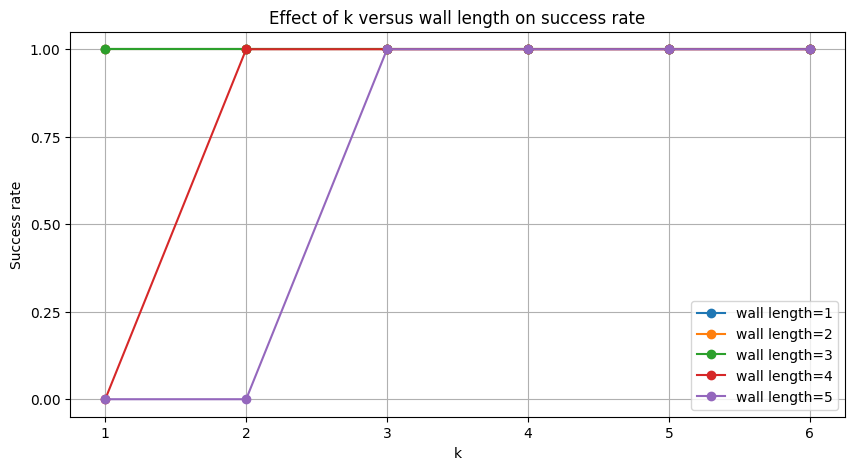

In [13]:
def run_on_the_fly_episode(test_env, agents, Qstar, k, walls, max_steps=100):
    """Run one episode with on-the-fly adaptation and return whether the goal was reached."""
    local_Qstar = {i: {state: values.copy() for state, values in Qstar[i].items()} for i in Qstar}
    reset_with_walls(test_env, walls, if_reset=True)

    for step in range(max_steps):
        safety_results = n_steps_safety_judger(k, test_env, agents, local_Qstar)
        actions = []

        for i, agent in enumerate(agents):
            current_state = test_env.get_agent_position(i)

            if not safety_results[i]['is_safe']:
                local_Qstar[i], _ = k_Qlearning(
                    k,
                    local_Qstar[i],
                    i,
                    test_env,
                    agent,
                    learning_rate=0.1,
                    discount_factor=0.95,
                    init_mode="Qstar",
                    convergence_threshold=1e-4,
                    max_iterations=100,
                    max_vision_range=None,
                )

            if current_state in local_Qstar[i]:
                action = int(np.argmax(local_Qstar[i][current_state]))
            else:
                action = 0

            safe_action = select_safe_action(
                current_state,
                action,
                compute_static_unsafe_set(test_env, agent_idx=i, n_steps=1, limited_vision=False),
                flag=False,
            )
            actions.append(safe_action)

        _, _, terminated, truncated, _ = test_env.step(actions)
        if terminated or truncated:
            return bool(terminated)

    return False


def evaluate_k_vs_wall_length(agents, Qstar, width, height, agent_positions, goal_positions, wall_lengths, ks, trials=3):
    results = {'wall_length': [], 'k': [], 'success_rate': []}

    for wall_length in wall_lengths:
        # Build a vertical wall directly between the agent and goal.
        # This makes the effect of k more visible when the corridor is blocked.
        walls = [(3, 1 + i) for i in range(wall_length)]

        for k in ks:
            successes = 0
            for trial in range(trials):
                test_env = MultiAgentEnvWrapper(
                    is_testing=True,
                    width=width,
                    height=height,
                    agent_positions=agent_positions,
                    goal_positions=goal_positions,
                    walls=walls,
                )
                if run_on_the_fly_episode(test_env, agents, Qstar, k=k, walls=walls, max_steps=50):
                    successes += 1

            success_rate = successes / trials
            results['wall_length'].append(wall_length)
            results['k'].append(k)
            results['success_rate'].append(success_rate)
            print(f"wall_length={wall_length}, k={k} -> success_rate={success_rate:.2f}")

    return pd.DataFrame(results)


# Re-use the same agent and goal positions, but make the wall directly block the straight path.
wall_lengths = [1, 2, 3, 4, 5]
ks = [1, 2, 3, 4, 5, 6]

results_df = evaluate_k_vs_wall_length(
    agents,
    Qstar,
    width=width,
    height=height,
    agent_positions=agent_positions,
    goal_positions=goal_positions,
    wall_lengths=wall_lengths,
    ks=ks,
    trials=3,
)

summary = results_df.pivot(index='wall_length', columns='k', values='success_rate')
print("\nSuccess rate matrix (0.0 to 1.0):")
print(summary.round(2))

plt.figure(figsize=(10, 5))
for wall_length in wall_lengths:
    if wall_length in summary.index:
        row = summary.loc[wall_length]
        plt.plot(ks, row.values, marker='o', label=f"wall length={wall_length}")

plt.xlabel('k')
plt.ylabel('Success rate')
plt.title('Effect of k versus wall length on success rate')
plt.xticks(ks)
plt.yticks([0.0, 0.25, 0.5, 0.75, 1.0])
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

* A longer wall demands a larger planning horizon k.
* Small k values fail for long walls, while higher k values succeed.
* Wall length and k are directly related: the longer the wall, the larger k needs to be.

Intuitively, k is how far the agent can "look ahead". If the wall is short, it can find a detour nearby; if the wall is long, it needs to look further ahead to find a path around it before hitting it
